## COMPAS - 2 OBJECTIVES

### Logistic Regression

* **Dataset:** Compass
* **Task:** Classification
* **Target:** Two year recidivism
* **Objectives:** Non-white and White individuals

### Methods

* **ML_MOO**
* **MONISE**
* **Random Weights**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math
import numpy as np
import pandas as pd

from sklearn.metrics import log_loss
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [ ]:
from ml_moo import moo
from ml_moo import MooScalarization
from ml_moo import get_objectives
from ml_moo.analysis.visualization import plot_pareto_2d, plot_hypervolume
from ml_moo.scalarization.two_objs_fairness_logreg import LogRegFairScalarization
from ml_moo.scalarization.moo_scalarization import Scalarization

### Dataset and Model

In [4]:
# Setting a seed for reproducibility
seed = 42

In [5]:
data = pd.read_csv("dataset/compas_onerace.csv")
fair_feature = "not_white"
pred_feature = "Two_yr_Recidivism"
data = data.drop("Unnamed: 0", axis=1)

categories_fair_class = []

for index, row in data.iterrows():
    if row[pred_feature] == -1:
        categories_fair_class.append(row[fair_feature])
    else:
        categories_fair_class.append(row[fair_feature]+2)

X_all = data.drop([pred_feature], axis=1)
# y = data[pred_feature]
y_all = (data[pred_feature] + 1)//2

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, 
                                                    test_size = int(data.shape[0]*0.5),
                                                    stratify = categories_fair_class,
                                                    random_state = seed)


In [6]:
#tol = 10**-3
#max_iter = 100

tol = 10**-8
max_iter = 10


In [7]:
lambd = math.exp(-100)

reg = LogisticRegression(solver = 'lbfgs',
                           class_weight = None,
                           penalty = 'l2',
                           max_iter = max_iter,
                           tol = tol, 
                           C = 1/lambd,
                           warm_start = True)

In [8]:
def train_logreg_fair(model, X, y, fair_feat, fair_att, w):
    """
    Treina o modelo com sample weights balanceadas por grupo de fairness.
    Retorna a loss por grupo.
    """
    # Gera os sample_weights com base nos grupos
    fair_weight = w
    sample_weight = X[fair_feat].replace({
        ff: fw / sum(X[fair_feat] == ff) 
        for ff, fw in zip(fair_att, fair_weight)
    }) + 1e-20

    # Treina o modelo
    model.fit(X, y, sample_weight=sample_weight.to_numpy())

    # Avaliação: log_loss por grupo
    y_pred = model.predict_proba(X)
    objs = []
    for i, feat in enumerate(fair_att):
        fair_weight = np.zeros(len(fair_att))
        fair_weight[i] = 1
        sample_weight = X[fair_feat].replace({
            ff: fw / sum(X[fair_feat] == ff) 
            for ff, fw in zip(fair_att, fair_weight)
            }) 
        objs.append(log_loss(y, y_pred, sample_weight=sample_weight))
    return np.array(objs), model, None

In [9]:
fair_feat = fair_feature
fair_att = sorted(X_all[fair_feat].unique())

# Train function to be passed in scalarization
def train_fn_logreg(model_reg, w):
    return train_logreg_fair(model_reg, X_train, y_train, fair_feat, fair_att, w)

## Multi Objective Optimization Process

In [10]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 50,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
num_objs = 2
results = {}

In [11]:
# Logistic Regression with equal weight to use as baseline
#equal = MooScalarization(reg, train_fn_logreg, num_objs)
#equal.optimize(np.array([0.5, 0.5]))

In [12]:
w_scalar = MooScalarization(reg, train_fn_logreg, num_objs)

In [13]:
equal = LogRegFairScalarization(X=X_train, y=y_train, fair_feat=fair_feature)
equal.optimize(np.array([0.5, 0.5]))

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
method = 'mola'
scalarization = LogRegFairScalarization(X=X_train, y=y_train, fair_feat=fair_feature)
moopt = moo(scalarization).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

13:41:44 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 50, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
13:41:44 | DEBUG | ml_moo | Finding 1th individual minimum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
13:41:44 | DEBUG | ml_moo | Finding 2th individual minimum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. O

new solution added [0.61283434 0.61719586]
new solution added [0.61353587 0.61673331]
new solution added [0.61319732 0.61688808]
new solution added [0.61246832 0.61810781]
solution dominated [0.61260705 0.6189783 ]
new solution added [0.61259675 0.61759223]
new solution added [0.61318331 0.61689762]


13:41:44 | DEBUG | ml_moo | Calculated weights: [0.46080623 0.53919377]
13:41:44 | DEBUG | ml_moo | Importance: 0.00017662857738531823
13:41:44 | DEBUG | ml_moo | Global lower bound (y*): [0.61246832 0.61662356]
13:41:44 | DEBUG | ml_moo | Iteration 7
13:41:44 | DEBUG | ml_moo | Solutions list: [array([0.61318331, 0.61689762]), array([0.61259675, 0.61759223]), array([0.61246832, 0.61810781]), array([0.61319732, 0.61688808]), array([0.61353587, 0.61673331]), array([0.61283434, 0.61719586]), array([0.61452791, 0.61662356])]
13:41:44 | INFO | ml_moo | Best solution found.


KeyboardInterrupt: 

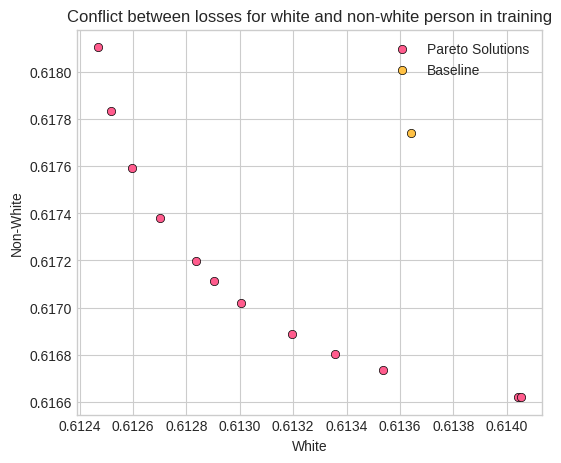

In [ ]:
title="Conflict between losses for white and non-white person in training"
plot_pareto_2d(objectives=objs, 
               labels=("White", "Non-White"), 
               title=title,
               point = equal.objs,
               color="#FF5C8D"
               )

In [ ]:
#method = 'mola'
#moopt = moo(w_scalar)
#moo_solutions[method] = moopt.mo_optimization(method, **opt_params)

In [ ]:
method = 'mola'
scalarization = LogRegFairScalarization(X=X_train, y=y_train, fair_feat=fair_feature, gradient=True)
moopt = moo(scalarization).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
#hypervolume_values = compute_hypervolume_progress(objs)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": moopt.get_models() if hasattr(moopt, "get_models") else None,
                "hypervolume": hypervolume_values
            }

In [ ]:
methods = [
    'mola', 
    'monise', 
    'random_weight'
    ]

## Comparison between MOO methods

In [ ]:
from ml_moo.tests.experiments.run import run_experiments
from ml_moo.analysis.moo_analyzer import Analyzer

23:35:03 | DEBUG | ml_moo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 50, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
23:35:03 | DEBUG | ml_moo | Finding 1th individual minimum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
23:35:03 | DEBUG | ml_moo | Finding 2th individual minimum
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. O

Running MOLA...
new solution added [0.61283158 0.61719796]
new solution added [0.61351914 0.61673736]
new solution added [0.61314523 0.61691569]
new solution added [0.61246839 0.6181067 ]
solution dominated [0.61260705 0.6189783 ]


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
23:35:03 | DEBUG | ml_moo | Calculated weights: [0.47367665 0.52632335]
23:35:03 | DEBUG | ml_moo | Importance: 0.00016485616846118045
23:35:03 | DEBUG | ml_moo | Global lower bound (y*): [0.61246839 0.61662356]
23:35:03 | DEBUG | ml_moo | Iteration 6
23:35:03 | DEBUG | ml_moo | Solutions list: [array([0.61259664, 0.61759108]), array([0.61246839, 0.6181067 ]), array([0.61314523, 0.61691569]), array([0.61351914, 0.61673736]), array([0.61283158, 0.61719

new solution added [0.61259664 0.61759108]
new solution added [0.61296595 0.61705309]
new solution added [0.61269543 0.61738817]
new solution added [0.61331977 0.61681825]


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
23:35:03 | DEBUG | ml_moo | Calculated weights: [0.79165443 0.20834557]
23:35:03 | DEBUG | ml_moo | Importance: 0.00011167146369828185
23:35:03 | DEBUG | ml_moo | Global lower bound (y*): [0.61246839 0.61661719]
23:35:03 | DEBUG | ml_moo | Iteration 10
23:35:03 | DEBUG | ml_moo | Solutions list: [array([0.61406704, 0.61661719]), array([0.61331977, 0.61681825]), array([0.61269543, 0.61738817]), array([0.61296595, 0.61705309]), array([0.61259664, 0.6175

...

23:35:06 | DEBUG | ml_moo | Calculated weights: [0.19156172 0.80843828]
23:35:06 | DEBUG | ml_moo | Importance: 5.142791010759318e-05
23:35:06 | DEBUG | ml_moo | Global lower bound (y*): [0.61246839 0.61661719]
23:35:06 | DEBUG | ml_moo | Iteration 45
23:35:06 | DEBUG | ml_moo | Solutions list: [array([0.61373172, 0.61667357]), array([0.61373222, 0.61667345]), array([0.61373223, 0.61667345]), array([0.61373423, 0.61667297]), array([0.61373224, 0.61667344]), array([0.61373174, 0.61667356]), array([0.61373219, 0.61667346]), array([0.61373083, 0.61667378]), array([0.61373223, 0.61667345]), array([0.61373052, 0.61667386]), array([0.61369592, 0.61668236]), array([0.61376746, 0.61666541]), array([0.61368107, 0.61668737]), array([0.61280137, 0.61723116]), array([0.61318029, 0.61689415]), array([0.61262249, 0.61753032]), array([0.61282709, 0.61719785]), array([0.61251312, 0.61785587]), array([0.61253796, 0.61776273]), array([0.61299408, 0.6170279 ]), array([0.61292342, 0.61709279]), array([0.6

new solution added [0.61373219 0.61667346]
new solution added [0.61373219 0.61667346]
new solution added [0.61375465 0.61666825]


23:35:06 | DEBUG | ml_moo | Calculated weights: [0.19156172 0.80843828]
23:35:06 | DEBUG | ml_moo | Importance: 5.1427910107482155e-05
23:35:06 | DEBUG | ml_moo | Global lower bound (y*): [0.61246839 0.61661719]
23:35:06 | DEBUG | ml_moo | Iteration 48
23:35:06 | DEBUG | ml_moo | Solutions list: [array([0.61375465, 0.61666825]), array([0.61373219, 0.61667346]), array([0.61373219, 0.61667346]), array([0.61373172, 0.61667357]), array([0.61373222, 0.61667345]), array([0.61373223, 0.61667345]), array([0.61373423, 0.61667297]), array([0.61373224, 0.61667344]), array([0.61373174, 0.61667356]), array([0.61373219, 0.61667346]), array([0.61373083, 0.61667378]), array([0.61373223, 0.61667345]), array([0.61373052, 0.61667386]), array([0.61369592, 0.61668236]), array([0.61376746, 0.61666541]), array([0.61368107, 0.61668737]), array([0.61280137, 0.61723116]), array([0.61318029, 0.61689415]), array([0.61262249, 0.61753032]), array([0.61282709, 0.61719785]), array([0.61251312, 0.61785587]), array([0.

new solution added [0.61373244 0.6166734 ]
new solution added [0.61376839 0.61666517]
new solution added [0.61373199 0.61667351]


23:35:06 | DEBUG | ml_moo | Calculated weights: [0.18269952 0.81730048]
23:35:06 | DEBUG | ml_moo | Importance: 5.151463878005913e-05
23:35:06 | DEBUG | ml_moo | Global lower bound (y*): [0.61246839 0.61661719]
23:35:06 | DEBUG | ml_moo | Iteration 51
23:35:06 | DEBUG | ml_moo | Solutions list: [array([0.61373199, 0.61667351]), array([0.61376839, 0.61666517]), array([0.61373244, 0.6166734 ]), array([0.61375465, 0.61666825]), array([0.61373219, 0.61667346]), array([0.61373219, 0.61667346]), array([0.61373172, 0.61667357]), array([0.61373222, 0.61667345]), array([0.61373223, 0.61667345]), array([0.61373423, 0.61667297]), array([0.61373224, 0.61667344]), array([0.61373174, 0.61667356]), array([0.61373219, 0.61667346]), array([0.61373083, 0.61667378]), array([0.61373223, 0.61667345]), array([0.61373052, 0.61667386]), array([0.61369592, 0.61668236]), array([0.61376746, 0.61666541]), array([0.61368107, 0.61668737]), array([0.61280137, 0.61723116]), array([0.61318029, 0.61689415]), array([0.6

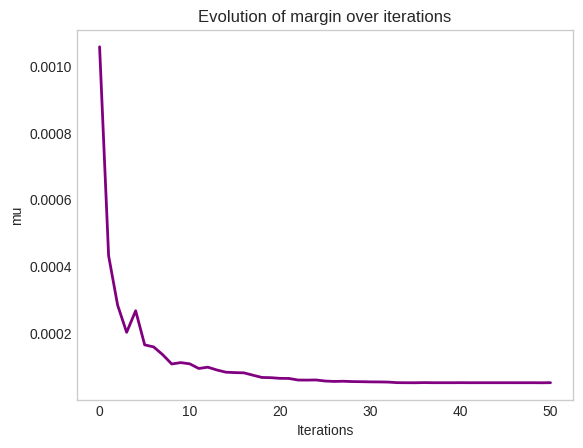

23:35:07 | INFO | ml_moo | Fit runtime: 3.76 seconds
23:35:07 | DEBUG | ml_moo | Filtered parameters for monise: {'nodeTimeLimit': 2, 'targetSize': 50, 'targetGap': 0, 'nodeGap': 0.05, 'norm': False}
23:35:07 | DEBUG | ml_moo.moo.monise | Finding 1th individual minima
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
23:35:07 | DEBUG | ml_moo.moo.monise | Finding 2th individual minima
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: Conv

Running MONISE...
monise


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
23:35:07 | DEBUG | ml_moo.moo.monise | 3th solution - importance: 1.0
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the docum

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
23:35:07 | DEBUG | ml_moo.moo.monise | 13th solution - importance: 0.056833859174951394
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

...

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
23:35:10 | DEBUG | ml_moo.moo.monise | 49th solution - importance: 0.001498003066800883
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


23:35:10 | WARNING | ml_moo | Ignored parameters for random_weights: {'nodeTimeLimit', 'nodeGap', 'targetGap'}
23:35:10 | DEBUG | ml_moo | Filtered parameters for random_weights: {'targetSize': 50, 'norm': False}
23:35:10 | DEBUG | ml_moo.moo.random_weights | Finding 1th individual minima
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
23:35:10 | DEBUG | ml_moo.moo.random_weights | Finding 2th individual minima
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear

Running RANDOM_WEIGHT...


/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
23:35:10 | DEBUG | ml_moo.moo.random_weights | 26th solution
/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation 

In [ ]:
experiment_results, pareto_dict, hypervolumes_dict = run_experiments(
                                                            methods = methods,
                                                            opt_params = opt_params,
                                                            model = reg,
                                                            train_fn = train_fn_logreg,
                                                            num_objs = num_objs,
                                                            mola_hv = False
                                                            )

23:59:48 | WARNING | ml_moo | [Methods have different numbers of solutions: {50, 46}


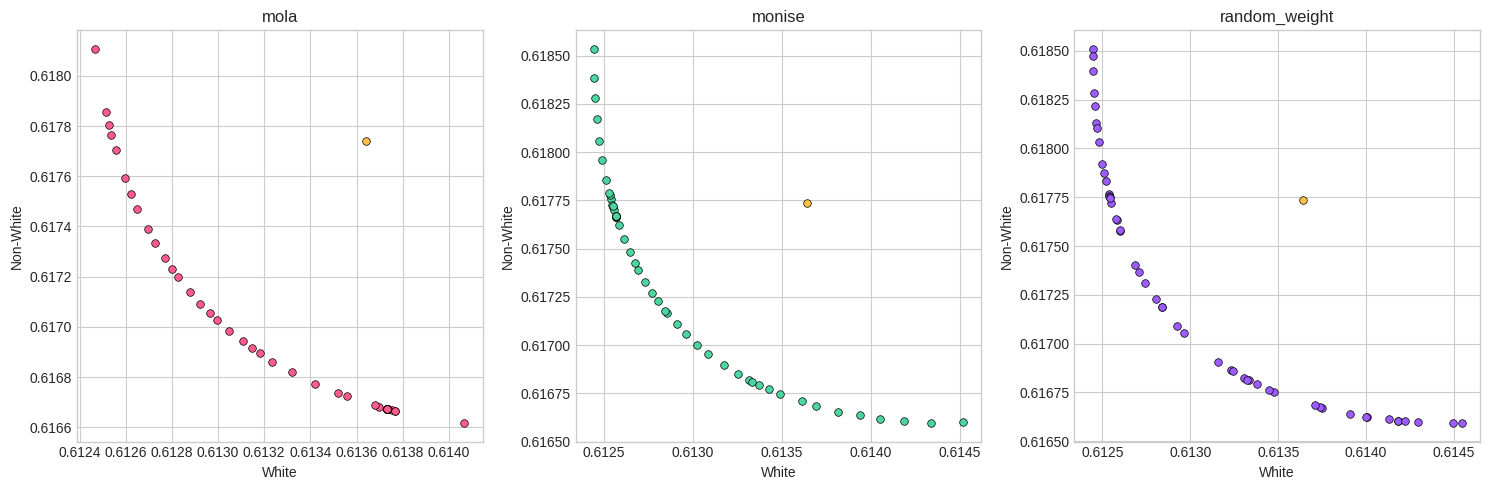

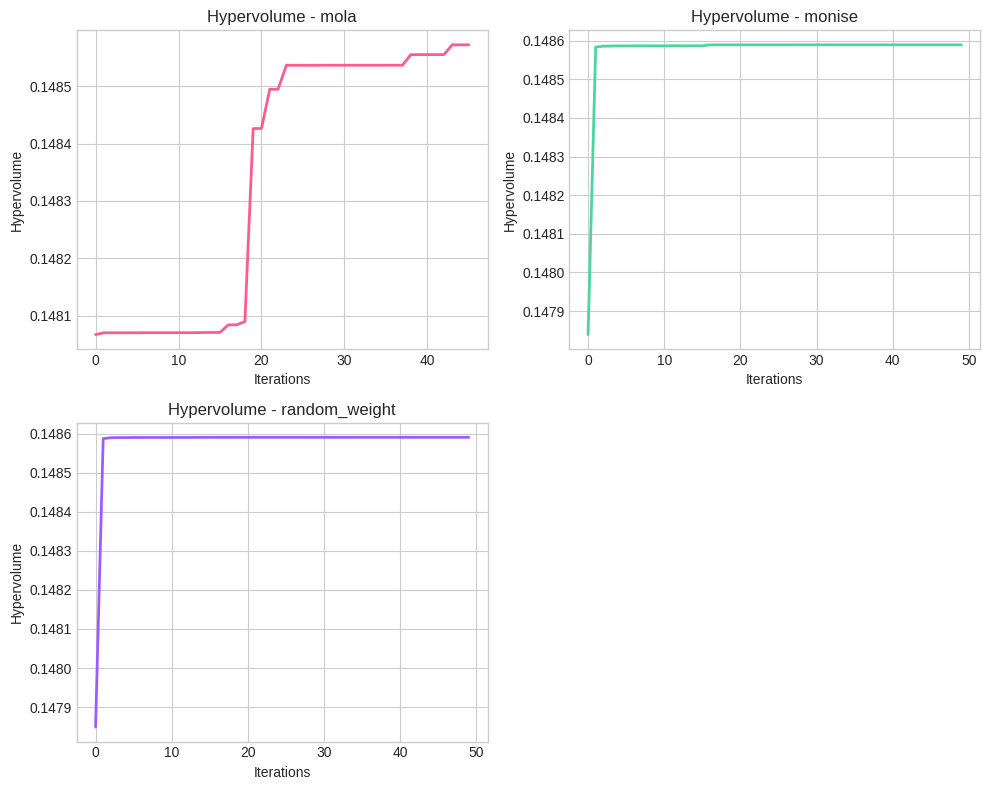

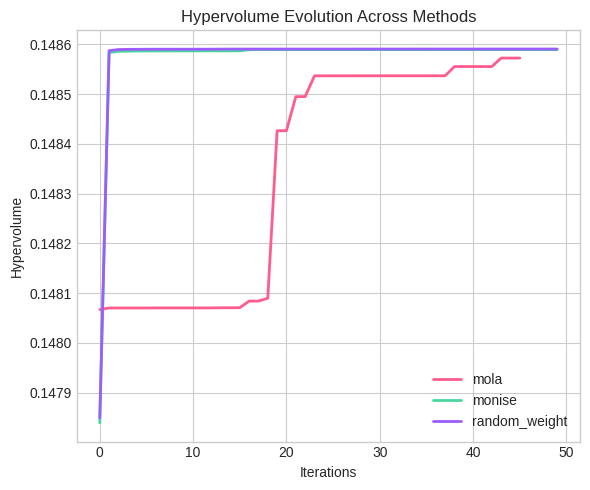

[Analyzer] Visualization complete.


In [ ]:
# pareto_dict = {
#         method: res["objectives"]
#         for method, res in results.items()
#         if "objectives" in res
#     }
# 
# hypervolumes_dict = {
#         method: res["hypervolume"]
#         for method, res in results.items()
#         if "hypervolume" in res
#     }
colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
axis_label = ["White", "Non-White"]
Analyzer.run_multiple(pareto_dict = pareto_dict,
                      hypervolumes_values = hypervolumes_dict,
                      show_pareto = True, 
                      show_hypervolume = True,
                      subplots = True,
                      subplots_hv = True,
                      colors_pareto=colors_hv,
                      colors_hv=colors_hv,
                      point = equal.objs,
                      axis_label=axis_label
                      )